# EDA: Traffic Law RAG Data

Kiểm tra dữ liệu đang cấp cho hệ thống RAG luật giao thông:

- PDF gốc và cache extraction.
- Records đã xử lý trong `data/processed/*.extracted.json`.
- Chunks trong `data/chunks/*.jsonl`.
- Metadata và ảnh crop biển báo trong `data/processed/sign_assets`.
- Dữ liệu bảng trong records/chunks và thư mục ảnh bảng nếu có.
- QA pairs và ground truth đánh giá RAG.
- Các kiểm tra dữ liệu trước khi reindex hoặc chạy evaluation.

## 1. Setup

In [33]:
from __future__ import annotations

import json
import math
import os
import re
import statistics
import tempfile
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

try:
    import pandas as pd
except ImportError:
    pd = None

plt = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "EDA":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
HANDMADE_DIR = PROCESSED_DIR / "handmade"
CHUNKS_DIR = DATA_DIR / "chunks"
QA_DIR = DATA_DIR / "qa_pairs"
EVAL_DIR = DATA_DIR / "eval"
SIGN_ASSET_DIR = PROCESSED_DIR / "sign_assets"
TABLE_IMAGE_DIR = PROCESSED_DIR / "table_imgs"
GRAPH_DIR = DATA_DIR / "graph"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Project root: /Users/dodat/Downloads/Legal-QA-Traffic-Laws
Data dir exists: True


In [34]:
def read_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                rows.append({"_parse_error": str(exc), "_line_no": line_no, "_raw": line[:300]})
    return rows


def as_df(rows: list[dict[str, Any]]):
    if pd is None:
        return rows
    return pd.DataFrame(rows)


def show_table(rows: list[dict[str, Any]], limit: int = 20):
    if pd is None:
        for row in rows[:limit]:
            print(row)
        return
    display(pd.DataFrame(rows).head(limit))


def text_len(value: Any) -> int:
    if value is None:
        return 0
    return len(str(value).strip())


def token_count(value: Any) -> int:
    return len(re.findall(r"\w+", str(value or ""), flags=re.UNICODE))


def quantiles(values: list[int | float]) -> dict[str, float]:
    values = [v for v in values if v is not None]
    if not values:
        return {"min": 0, "p50": 0, "p90": 0, "p95": 0, "max": 0, "mean": 0}
    values = sorted(values)
    def q(p: float) -> float:
        idx = min(len(values) - 1, max(0, round((len(values) - 1) * p)))
        return float(values[idx])
    return {
        "min": float(values[0]),
        "p50": q(0.50),
        "p90": q(0.90),
        "p95": q(0.95),
        "max": float(values[-1]),
        "mean": float(statistics.mean(values)),
    }


def exists_in_project(path_value: Any) -> bool:
    if not path_value:
        return False
    path = Path(str(path_value))
    if path.is_absolute():
        return path.exists()
    return (PROJECT_ROOT / path).exists()

## 2. Data Inventory

Mục tiêu: kiểm tra số lượng và kích thước các nhóm dữ liệu chính trong repo.

In [35]:
inventory = []
for label, directory, pattern in [
    ("raw_pdfs", RAW_DIR, "*.pdf"),
    ("llamaparse_cache", RAW_DIR, "*.llamaparse.v4.json"),
    ("extracted_records", PROCESSED_DIR, "*.extracted.json"),
    ("extraction_meta", PROCESSED_DIR, "*.extracted.json.meta.json"),
    ("chunks", CHUNKS_DIR, "*.chunks.jsonl"),
    ("chunk_meta", CHUNKS_DIR, "*.chunks.jsonl.meta.json"),
    ("handmade_qa", HANDMADE_DIR, "*.json"),
    ("synthetic_qa", QA_DIR, "*.qa.json"),
    ("eval_ground_truth", EVAL_DIR, "*.jsonl"),
    ("sign_crops", SIGN_ASSET_DIR, "*.png"),
    ("table_images", TABLE_IMAGE_DIR, "*.png"),
    ("graph_exports", GRAPH_DIR, "*.json"),
]:
    files = sorted(directory.glob(pattern)) if directory.exists() else []
    inventory.append({
        "dataset": label,
        "directory": str(directory.relative_to(PROJECT_ROOT)) if directory.exists() else str(directory),
        "files": len(files),
        "size_mb": round(sum(p.stat().st_size for p in files) / 1024 / 1024, 2),
    })

show_table(inventory)

,dataset,directory,files,size_mb
0,raw_pdfs,data/raw,7,49.18
1,llamaparse_cache,data/raw,2,2.23
2,extracted_records,data/processed,7,41.96
3,extraction_meta,data/processed,7,0.00
4,chunks,data/chunks,7,7.44
5,chunk_meta,data/chunks,7,0.00
6,handmade_qa,data/processed/handmade,7,0.32
7,synthetic_qa,data/qa_pairs,7,19.28
8,eval_ground_truth,data/eval,1,1.52
9,sign_crops,data/processed/sign_assets,659,25.76


### How To Read: Data Inventory

Bảng này cho biết repo đang có đủ các nhóm dữ liệu đầu vào và dữ liệu trung gian.

- `files`: số file trong từng nhóm dữ liệu. Nếu một nhóm quan trọng bằng `0`, pipeline phía sau có thể không chạy đủ.
- `size_mb`: kích thước dữ liệu. Giá trị này giúp phát hiện dữ liệu rỗng, cache quá lớn hoặc asset sinh ra bất thường.
- `raw_pdfs`: PDF gốc dùng để tái tạo extraction.
- `extracted_records`: records đã parse từ PDF, là nguồn chính để sync sang store.
- `chunks`: đơn vị được index cho retrieval.
- `sign_crops`: ảnh crop biển báo dùng cho lookup ảnh.
- `eval_ground_truth`: dữ liệu đánh giá RAG.

Kết quả hiện tại: repo có 7 PDF gốc, 7 extracted record files, 7 chunk files, 659 ảnh crop biển báo và 1 file ground truth. Nhóm `table_images` đang bằng 0, nghĩa là dữ liệu bảng hiện chủ yếu nằm trong JSON records/chunks, chưa có ảnh bảng riêng.

## 3. Extracted Records

Kiểm tra records do parser tạo ra. Đây là nguồn dữ liệu để sync sang PostgreSQL, Qdrant và Neo4j.

In [36]:
record_rows = []
all_records = []
for path in sorted(PROCESSED_DIR.glob("*.extracted.json")):
    records = read_json(path)
    if not isinstance(records, list):
        continue
    all_records.extend(records)
    record_rows.append({
        "file": path.name,
        "records": len(records),
        "doc_names": len({r.get("doc_name", "") for r in records}),
        "record_types": dict(Counter(r.get("record_type", "") or "missing" for r in records).most_common()),
        "with_tables": sum(bool(r.get("tables") or r.get("table_refs")) for r in records),
        "with_figures": sum(bool(r.get("figures") or r.get("figure_refs")) for r in records),
        "with_sign_info": sum(bool(r.get("sign_info")) for r in records),
        "missing_id": sum(not r.get("id") for r in records),
        "missing_content": sum(not (r.get("content") or r.get("original_text") or r.get("meaning_and_usage")) for r in records),
        "missing_reference": sum(not r.get("legal_reference") for r in records),
    })

show_table(record_rows, limit=50)
print(f"Total extracted records: {len(all_records):,}")

,file,records,doc_names,record_types,with_tables,with_figures,with_sign_info,missing_id,missing_content,missing_reference
0,168-nd-cp.signed.pdf.extracted.json,2018,1,"{'enriched_rule': 1994, 'source_legal_unit': 24}",0,0,0,0,1994,0
1,336-2025-nd-cp-22122025-signed-176654825698517...,525,1,"{'enriched_rule': 501, 'source_legal_unit': 24}",0,0,0,0,501,0
2,35-2024-qh15.pdf.extracted.json,1911,1,"{'enriched_rule': 1902, 'source_legal_unit': 9}",81,0,0,0,0,0
3,35-bgtvt.pdf.extracted.json,1720,1,"{'enriched_rule': 1645, 'source_legal_unit': 75}",261,0,0,0,0,0
4,36-2024-qh15.pdf.extracted.json,355,1,"{'enriched_rule': 354, 'source_legal_unit': 1}",7,0,0,0,0,0
5,36-2024-qh15_tiep.pdf.extracted.json,1699,1,"{'enriched_rule': 1680, 'source_legal_unit': 19}",44,0,0,0,0,0
6,51-bgtvt-kem.pdf.extracted.json,1170,1,"{'enriched_rule': 910, 'source_legal_unit': 260}",478,726,910,0,2,0


Total extracted records: 9,398


### How To Read: Extracted Records Per File

Bảng này đánh giá chất lượng records sau extraction theo từng văn bản.

- `records`: số records parser tạo ra từ mỗi văn bản.
- `doc_names`: số tên văn bản xuất hiện trong file. Giá trị cao bất thường có thể do parser gán sai tên tài liệu.
- `record_types`: phân bố loại record, giúp biết dữ liệu đang là legal units hay enriched rules.
- `with_tables`: số records có dữ liệu bảng hoặc tham chiếu bảng.
- `with_figures`: số records có hình hoặc tham chiếu hình.
- `with_sign_info`: số records có metadata biển báo.
- `missing_id`: records thiếu ID. Đây là lỗi nghiêm trọng vì store/citation cần ID ổn định.
- `missing_content`: records không có text usable.
- `missing_reference`: records thiếu căn cứ pháp lý.

Kết quả hiện tại: có 9,398 extracted records và không thiếu `legal_reference`. Điều này tốt cho citation. Tuy nhiên cần đọc tiếp phần duplicate ID và chunk mapping vì legal reference đầy đủ không đồng nghĩa retrieval index đã nhất quán.

In [37]:
record_ids = [r.get("id") for r in all_records if r.get("id")]
duplicate_ids = [item for item, count in Counter(record_ids).items() if count > 1]
content_lengths = [token_count(r.get("content") or r.get("original_text") or r.get("meaning_and_usage")) for r in all_records]
record_type_counts = Counter(r.get("record_type", "") or "missing" for r in all_records)

audit_rows = [
    {"check": "duplicate_record_ids", "value": len(duplicate_ids), "status": "PASS" if not duplicate_ids else "WARN"},
    {"check": "empty_or_tiny_records_lt_5_tokens", "value": sum(v < 5 for v in content_lengths), "status": "WARN"},
    {"check": "records_missing_legal_reference", "value": sum(not r.get("legal_reference") for r in all_records), "status": "PASS" if not sum(not r.get("legal_reference") for r in all_records) else "WARN"},
    {"check": "unique_record_types", "value": len(record_type_counts), "status": "INFO"},
]
show_table(audit_rows)
print("Record type counts:")
print(record_type_counts.most_common(20))
print("Content token quantiles:")
print(quantiles(content_lengths))

,check,value,status
0,duplicate_record_ids,7,WARN
1,empty_or_tiny_records_lt_5_tokens,2527,WARN
2,records_missing_legal_reference,0,PASS
3,unique_record_types,2,INFO


Record type counts:
[('enriched_rule', 8986), ('source_legal_unit', 412)]
Content token quantiles:
{'min': 0.0, 'p50': 20.0, 'p90': 65.0, 'p95': 82.0, 'max': 697.0, 'mean': 28.321664183868908}


### How To Read: Record-Level Checks

Cell này kiểm tra tính ổn định của records trước khi sync sang store.

- `duplicate_record_ids`: số ID record bị trùng. ID trùng có thể làm ghi đè dữ liệu trong PostgreSQL/Qdrant hoặc gây citation sai.
- `empty_or_tiny_records_lt_5_tokens`: records quá ngắn. Một số record ngắn là bình thường, nhưng số lượng lớn có thể làm nhiễu retrieval.
- `records_missing_legal_reference`: records thiếu căn cứ pháp lý. Với legal QA, giá trị này nên bằng 0.
- `unique_record_types`: số loại record đang có.
- `Content token quantiles`: phân phối độ dài nội dung record. `p50` là median, `p95` cho biết nhóm record dài ở đuôi phân phối.

Kết quả hiện tại: có 7 duplicate IDs và 2,527 records dưới 5 tokens. Đây là cảnh báo cần xử lý sau, nhất là duplicate IDs. Legal reference hiện bằng 0 missing nên phần căn cứ pháp lý ổn.

## 4. Chunks And Retrieval Metadata

Chunks là đơn vị truy xuất chính. Phần này kiểm tra độ dài, metadata và khả năng liên kết với records.

In [38]:
all_chunks = []
chunk_rows = []
for path in sorted(CHUNKS_DIR.glob("*.chunks.jsonl")):
    chunks = read_jsonl(path)
    all_chunks.extend(chunks)
    lengths = [token_count(c.get("text")) for c in chunks]
    chunk_rows.append({
        "file": path.name,
        "chunks": len(chunks),
        "doc_names": len({c.get("doc_name", "") for c in chunks}),
        "with_article": sum(bool(c.get("article_num")) for c in chunks),
        "with_tables": sum(bool(c.get("tables")) for c in chunks),
        "with_figures": sum(bool(c.get("figures")) for c in chunks),
        "sign_pages": sum(bool(c.get("is_sign_page")) for c in chunks),
        "with_image_path": sum(bool(c.get("image_path")) for c in chunks),
        "p50_tokens": quantiles(lengths)["p50"],
        "p95_tokens": quantiles(lengths)["p95"],
    })

show_table(chunk_rows, limit=50)
print(f"Total chunks: {len(all_chunks):,}")

,file,chunks,doc_names,with_article,with_tables,with_figures,sign_pages,with_image_path,p50_tokens,p95_tokens
0,168-nd-cp.signed.chunks.jsonl,946,1,941,0,0,0,946,34.0,170.0
1,336-2025-nd-cp-22122025-signed-176654825698517...,446,1,442,0,0,0,446,28.0,77.0
2,35-2024-qh15.chunks.jsonl,873,1,866,28,0,0,873,32.0,90.0
3,35-bgtvt.chunks.jsonl,818,1,808,84,0,0,818,34.0,159.0
4,36-2024-qh15.chunks.jsonl,248,1,245,6,0,0,248,28.0,94.0
5,36-2024-qh15_tiep.chunks.jsonl,749,1,740,19,0,0,749,33.0,105.0
6,51-bgtvt-kem.chunks.jsonl,414,1,414,299,110,0,414,75.0,1077.0


Total chunks: 4,494


### How To Read: Chunk Summary

Bảng này kiểm tra chunk index theo từng văn bản.

- `chunks`: số chunks sinh ra từ file.
- `with_article`: chunks có metadata điều luật. Metadata này rất quan trọng cho filter theo điều/khoản.
- `with_tables`: chunks chứa bảng.
- `with_figures`: chunks chứa hình.
- `sign_pages`: chunks thuộc trang biển báo.
- `with_image_path`: chunks có đường dẫn ảnh trang/crop.
- `p50_tokens`, `p95_tokens`: độ dài chunks. Chunks quá ngắn dễ thiếu ngữ cảnh; chunks quá dài dễ làm retrieval/rerank kém chính xác.

Kết quả hiện tại: có 4,494 chunks. QCVN 41 có `p95_tokens` cao hơn hẳn vì phụ lục biển báo/hình thường dài và dày metadata. Đây là lý do route biển báo nên lọc riêng theo sign metadata thay vì để lẫn với toàn bộ legal text.

In [39]:
chunk_ids = {c.get("source_chunk_id") for c in all_chunks if c.get("source_chunk_id")}
record_chunk_ids = {r.get("source_chunk_id") for r in all_records if r.get("source_chunk_id")}
missing_chunk_backrefs = sorted(record_chunk_ids - chunk_ids)[:20]
chunk_lengths = [token_count(c.get("text")) for c in all_chunks]

retrieval_rows = [
    {"check": "records_with_source_chunk_id", "value": len(record_chunk_ids), "status": "INFO"},
    {"check": "chunk_ids", "value": len(chunk_ids), "status": "INFO"},
    {"check": "record_chunk_ids_missing_in_chunks", "value": len(record_chunk_ids - chunk_ids), "status": "PASS" if not (record_chunk_ids - chunk_ids) else "WARN"},
    {"check": "chunks_lt_20_tokens", "value": sum(v < 20 for v in chunk_lengths), "status": "WARN"},
    {"check": "chunks_gt_900_tokens", "value": sum(v > 900 for v in chunk_lengths), "status": "WARN"},
]
show_table(retrieval_rows)
if missing_chunk_backrefs:
    print("Example missing chunk ids:")
    print(missing_chunk_backrefs)
print("Chunk token quantiles:")
print(quantiles(chunk_lengths))

,check,value,status
0,records_with_source_chunk_id,5124,INFO
1,chunk_ids,4484,INFO
2,record_chunk_ids_missing_in_chunks,656,WARN
3,chunks_lt_20_tokens,1105,WARN
4,chunks_gt_900_tokens,29,WARN


Example missing chunk ids:
['luật_trật_tự_atgt_2024_(tiếp)_0_0_0_33d6ce', 'luật_trật_tự_atgt_2024_(tiếp)_0_0_0_61069c', 'luật_trật_tự_atgt_2024_(tiếp)_0_0_0_69f8f4', 'luật_trật_tự_atgt_2024_(tiếp)_24_3_0_bb6890', 'luật_trật_tự_atgt_2024_(tiếp)_25_1_0_23c34d', 'luật_trật_tự_atgt_2024_(tiếp)_26_0_0_907b30', 'luật_trật_tự_atgt_2024_(tiếp)_26_2_0_6662e1', 'luật_trật_tự_atgt_2024_(tiếp)_27_4_0_a17f94', 'luật_trật_tự_atgt_2024_(tiếp)_29_1_a_e829dc', 'luật_trật_tự_atgt_2024_(tiếp)_29_3_0_23b42d', 'luật_trật_tự_atgt_2024_(tiếp)_31_0_0_68cbcf', 'luật_trật_tự_atgt_2024_(tiếp)_31_1_0_756bf9', 'luật_trật_tự_atgt_2024_(tiếp)_31_2_0_a55086', 'luật_trật_tự_atgt_2024_(tiếp)_31_3_0_de11c3', 'luật_trật_tự_atgt_2024_(tiếp)_31_4_0_5c8058', 'luật_trật_tự_atgt_2024_(tiếp)_31_5_0_bf4428', 'luật_trật_tự_atgt_2024_(tiếp)_32_0_0_65bdef', 'luật_trật_tự_atgt_2024_(tiếp)_32_1_0_038216', 'luật_trật_tự_atgt_2024_(tiếp)_32_2_0_fc52de', 'luật_trật_tự_atgt_2024_(tiếp)_33_3_e_9e6c22']
Chunk token quantiles:
{'min': 2.0,

### How To Read: Chunk Mapping Checks

Cell này kiểm tra khả năng map từ records/ground truth về chunk index.

- `records_with_source_chunk_id`: số records có tham chiếu chunk gốc.
- `chunk_ids`: số chunk IDs hiện có trong index.
- `record_chunk_ids_missing_in_chunks`: records trỏ tới chunk ID không còn tồn tại. Giá trị này gây lỗi khi cần truy vết evidence.
- `chunks_lt_20_tokens`: chunks quá ngắn, có nguy cơ retrieval thiếu ngữ cảnh.
- `chunks_gt_900_tokens`: chunks quá dài, có nguy cơ retrieval lấy quá nhiều nhiễu.

Kết quả hiện tại: có 656 record chunk IDs không tồn tại trong chunk index, 1,105 chunks dưới 20 tokens và 29 chunks trên 900 tokens. Đây là cảnh báo quan trọng cho độ chính xác retrieval và evaluation.

## 5. Traffic Sign Assets

Mục tiêu: kiểm tra metadata biển báo, mã biển và đường dẫn ảnh crop.

In [40]:
sign_meta_path = SIGN_ASSET_DIR / "51-bgtvt-kem_meta.json"
sign_meta = read_json(sign_meta_path) if sign_meta_path.exists() else []
sign_records = [r for r in all_records if r.get("sign_info") or (r.get("record_type") or "").lower() == "sign"]

sign_codes_from_meta = [s.get("code") for s in sign_meta if isinstance(s, dict) and s.get("code")]
sign_codes_from_records = []
for r in sign_records:
    info = r.get("sign_info") or {}
    code_value = None
    if isinstance(info, dict):
        code_value = info.get("code") or info.get("sign_code")
    if code_value:
        sign_codes_from_records.append(code_value)

sign_rows = [
    {"metric": "sign_asset_meta_entries", "value": len(sign_meta)},
    {"metric": "unique_sign_codes_in_assets", "value": len(set(sign_codes_from_meta))},
    {"metric": "sign_records", "value": len(sign_records)},
    {"metric": "unique_sign_codes_in_records", "value": len(set(sign_codes_from_records))},
    {"metric": "png_crops", "value": len(list(SIGN_ASSET_DIR.glob("*.png"))) if SIGN_ASSET_DIR.exists() else 0},
    {"metric": "meta_entries_missing_image", "value": sum(not exists_in_project(s.get("image_path")) for s in sign_meta if isinstance(s, dict))},
]
show_table(sign_rows)
print("Top sign codes in assets:")
print(Counter(sign_codes_from_meta).most_common(20))

,metric,value
0,sign_asset_meta_entries,649
1,unique_sign_codes_in_assets,382
2,sign_records,910
3,unique_sign_codes_in_records,539
4,png_crops,659
5,meta_entries_missing_image,0


Top sign codes in assets:
[('P.101', 10), ('W.208', 8), ('W.211', 6), ('R.122', 5), ('I.401', 5), ('S.501', 5), ('P.121', 4), ('W.212', 4), ('R.404a', 4), ('R.411', 4), ('R.301a', 4), ('I.406', 4), ('I.414', 4), ('IE.464b', 4), ('IE.461c', 4), ('P.115', 4), ('P.127a', 4), ('W.204', 4), ('R.403a', 4), ('R.412a', 4)]


### How To Read: Sign Asset Metrics

Cell này kiểm tra dữ liệu phục vụ tra cứu biển báo.

- `sign_asset_meta_entries`: số entry metadata ảnh crop biển báo.
- `unique_sign_codes_in_assets`: số mã biển khác nhau có trong asset metadata.
- `sign_records`: số records liên quan biển báo trong extracted data.
- `unique_sign_codes_in_records`: số mã biển khác nhau trong records.
- `png_crops`: số file ảnh crop thực tế.
- `meta_entries_missing_image`: metadata có image path nhưng file không tồn tại.

Kết quả hiện tại: có 649 metadata entries, 382 mã biển unique, 659 PNG crops và không thiếu ảnh theo metadata. Đây là tín hiệu tốt cho route lookup biển báo. Số `sign_records` lớn hơn unique code là bình thường vì một biển có thể xuất hiện ở nhiều records/ngữ cảnh.

In [41]:
if sign_meta:
    sample_signs = []
    for s in sign_meta[:10]:
        sample_signs.append({
            "code": s.get("code"),
            "name": s.get("name"),
            "page": s.get("page"),
            "image_exists": exists_in_project(s.get("image_path")),
            "image_path": s.get("image_path"),
        })
    show_table(sample_signs)
else:
    print("No sign metadata found.")

,code,name,page,image_exists,image_path
0,P.101,Đườngcấm,19,True,data/processed/sign_assets/51-bgtvt-kem_P_101_...
1,P.111d,Cấmxebabánhloạikhôngcóđộngcơ(xíchlô),20,True,data/processed/sign_assets/51-bgtvt-kem_P_111d...
2,P.121,Cựlytốithiểugiữahaixe,20,True,data/processed/sign_assets/51-bgtvt-kem_P_121_...
3,P.125,Cấmvượt,20,True,data/processed/sign_assets/51-bgtvt-kem_P_125_...
4,DP.127,Biểnhếttốcđộtốiđachophéptheobiểnghép,20,True,data/processed/sign_assets/51-bgtvt-kem_DP_127...
5,P.136,Cấmđithẳng,21,True,data/processed/sign_assets/51-bgtvt-kem_P_136_...
6,P.101đ,ếnbiểnsố P.120khôngcần quyđịnh,21,True,data/processed/sign_assets/51-bgtvt-kem_P_101đ...
7,P.121v,àbiểnsốP.128cóhiệulựcđếnhếtkhoảngcáchcấmghitrên,21,True,data/processed/sign_assets/51-bgtvt-kem_P_121v...
8,P.123,"(a, b)vàbiểnsốP.129cóhiệulựctạikhuvựcđặtbiển.",22,True,data/processed/sign_assets/51-bgtvt-kem_P_123_...
9,P.125,", P.126, P.127(a, b, c), P.130, P.131(a, b, c)...",22,True,data/processed/sign_assets/51-bgtvt-kem_P_125_...


### How To Read: Sign Samples

Bảng sample dùng để kiểm tra thủ công nhanh vài biển báo đầu tiên.

- `code`: mã biển, ví dụ `P.101`.
- `name`: tên biển parser đọc được.
- `page`: trang PDF gốc.
- `image_exists`: file ảnh crop có tồn tại không.
- `image_path`: đường dẫn ảnh crop.

Kết quả hiện tại: các sample đầu có `image_exists=True`. Nếu sau này thấy `False`, cần kiểm tra lại `FigureExtractor` hoặc đường dẫn asset sau khi di chuyển dữ liệu.

## 6. Table Data

Dữ liệu bảng được kiểm tra riêng vì các câu hỏi về GPLX, mức phạt hoặc thông số kỹ thuật thường cần truy xuất theo dòng/cột.

In [42]:
table_records = []
for r in all_records:
    tables = r.get("tables") or []
    table_refs = r.get("table_refs") or []
    if tables or table_refs:
        table_records.append(r)

chunk_table_count = sum(bool(c.get("tables")) for c in all_chunks)
table_images = sorted(TABLE_IMAGE_DIR.glob("*.png")) if TABLE_IMAGE_DIR.exists() else []

table_rows = [
    {"metric": "records_with_tables_or_refs", "value": len(table_records)},
    {"metric": "chunks_with_tables", "value": chunk_table_count},
    {"metric": "table_image_files", "value": len(table_images)},
    {"metric": "records_with_table_refs_only", "value": sum(bool(r.get("table_refs")) and not bool(r.get("tables")) for r in table_records)},
]
show_table(table_rows)

sample_tables = []
for r in table_records[:10]:
    sample_tables.append({
        "id": r.get("id"),
        "doc_name": r.get("doc_name"),
        "legal_reference": r.get("legal_reference"),
        "tables": len(r.get("tables") or []),
        "table_refs": len(r.get("table_refs") or []),
        "content_preview": str(r.get("content") or r.get("original_text") or "")[:160],
    })
show_table(sample_tables)

,metric,value
0,records_with_tables_or_refs,871
1,chunks_with_tables,436
2,table_image_files,0
3,records_with_table_refs_only,0


,id,doc_name,legal_reference,tables,table_refs,content_preview
0,LUAT_DUONGBO_2024_A21_C3_P_C_c_88dd97,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",2,0,"Người quản lý, sử dụng đường bộ có trách nhiệm..."
1,LDB2024_A28_C5_D_d_593748,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,"Trường hợp đầu tư, xây dựng công trình thuộc k..."
2,LDB2024_A28_C5_E_d_593748,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,"Trong giai đoạn lập dự án đầu tư, thiết kế tri..."
3,LDB2024_A28_C10_01_0_04261f,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,Công trình đường bộ đang khai thác chưa bảo đả...
4,LDB2024_A28_C10_02_0_04261f,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,"Trong giai đoạn lập dự án đầu tư, thiết kế tri..."
5,LD2024_A29_C1_P1_0_6e92a3,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,"Đường bộ được thẩm tra, thẩm định về an toàn g..."
6,LD2024_A29_C1_P2_0_6e92a3,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,"Trong giai đoạn lập dự án đầu tư, thiết kế tri..."
7,LDB2024_A29_C2_01_0_32de93,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,Thẩm tra an toàn giao thông đường bộ là việc t...
8,LDB2024_A29_C2_02_0_32de93,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,"Trong giai đoạn lập dự án đầu tư, thiết kế tri..."
9,LUAT_DUONG_BO_2024_A40_C1_0_d944bf,Luật Đường bộ 2024,"{'document': 'Luật Đường bộ 2024', 'document_i...",1,0,Giao thông thông minh là việc ứng dụng các côn...


### How To Read: Table Data

Cell này kiểm tra dữ liệu bảng phục vụ các câu hỏi dạng lookup theo dòng/cột.

- `records_with_tables_or_refs`: số records có bảng hoặc tham chiếu bảng.
- `chunks_with_tables`: số chunks chứa dữ liệu bảng.
- `table_image_files`: số ảnh bảng đã crop riêng.
- `records_with_table_refs_only`: records chỉ có tham chiếu bảng nhưng không có payload bảng.

Kết quả hiện tại: có 871 records và 436 chunks liên quan bảng, nhưng `table_image_files=0`. Điều này nghĩa là table retrieval nên ưu tiên JSON structured data hiện có. Nếu muốn trả lời kèm ảnh bảng, cần bổ sung extraction/crop ảnh bảng.

## 7. QA And Evaluation Data

Kiểm tra handmade QA, synthetic QA và ground truth dùng cho `src/evaluation/rag_evaluator.py`.

In [43]:
handmade_rows = []
all_handmade = []
for path in sorted(HANDMADE_DIR.glob("*.json")):
    items = read_json(path)
    if not isinstance(items, list):
        continue
    for item in items:
        item = dict(item)
        item["_file"] = path.name
        all_handmade.append(item)
    handmade_rows.append({
        "file": path.name,
        "items": len(items),
        "missing_question": sum(not x.get("question") for x in items),
        "missing_answer": sum(not x.get("answer") for x in items),
        "missing_legal_basis": sum(not x.get("legal_basis") for x in items),
        "missing_reference_text": sum(not x.get("reference_text") for x in items),
    })
show_table(handmade_rows, limit=50)
print(f"Total handmade QA: {len(all_handmade):,}")

,file,items,missing_question,missing_answer,missing_legal_basis,missing_reference_text
0,168-nd-cp.signed.json,50,0,0,0,0
1,336nd.signed.json,50,0,0,0,0
2,35-2024-qh15.json,106,0,0,0,0
3,35-bgtvt.json,100,0,0,0,0
4,36-2024-qh15.json,50,0,0,0,0
5,36-2024-qh15_tiep.json,100,0,0,0,0
6,51-bgtvt-kem.json,100,0,0,0,0


Total handmade QA: 556


### How To Read: Handmade QA

Bảng này kiểm tra bộ QA thủ công theo từng file nguồn.

- `items`: số cặp hỏi đáp thủ công.
- `missing_question`: thiếu câu hỏi.
- `missing_answer`: thiếu câu trả lời.
- `missing_legal_basis`: thiếu căn cứ pháp lý.
- `missing_reference_text`: thiếu đoạn trích tham chiếu.

Kết quả hiện tại: có 556 handmade QA, không thiếu question/answer/legal basis/reference text. Bộ này phù hợp để kiểm tra nhanh hành vi trả lời có căn cứ.

In [44]:
synthetic_rows = []
all_synthetic = []
for path in sorted(QA_DIR.glob("*.qa.json")):
    items = read_json(path)
    if not isinstance(items, list):
        continue
    for item in items:
        item = dict(item)
        item["_file"] = path.name
        all_synthetic.append(item)
    synthetic_rows.append({
        "file": path.name,
        "items": len(items),
        "validated": sum(x.get("validated") is True for x in items),
        "adversarial": sum(x.get("is_adversarial") is True for x in items),
        "missing_citation": sum(not x.get("citation") for x in items),
        "missing_source_chunk_id": sum(not x.get("source_chunk_id") for x in items),
    })
show_table(synthetic_rows, limit=50)
print(f"Total synthetic QA: {len(all_synthetic):,}")
print("Intent counts:", Counter(x.get("intent", "missing") for x in all_synthetic).most_common(20))
print("Difficulty counts:", Counter(x.get("difficulty", "missing") for x in all_synthetic).most_common(20))

,file,items,validated,adversarial,missing_citation,missing_source_chunk_id
0,168-nd-cp.signed.pdf.qa.json,2422,2422,766,0,0
1,336-2025-nd-cp-22122025-signed-176654825698517...,1021,1021,343,0,0
2,35-2024-qh15.pdf.qa.json,2254,2254,530,0,0
3,35-bgtvt.pdf.qa.json,2152,2152,381,0,0
4,36-2024-qh15.pdf.qa.json,651,651,196,0,0
5,36-2024-qh15_tiep.pdf.qa.json,2238,2238,502,0,0
6,51-bgtvt-kem.pdf.qa.json,1809,1809,392,0,0


Total synthetic QA: 12,547
Intent counts: [('SCENARIO', 3861), ('PROCEDURE', 3235), ('DEFINITION', 3198), ('EXCEPTION', 946), ('PENALTY', 666), ('TECHNICAL_SPEC', 492), ('SIGN_MEANING', 149)]
Difficulty counts: [('EASY', 5818), ('MEDIUM', 5791), ('HARD', 938)]


### How To Read: Synthetic QA

Bảng này kiểm tra QA sinh tự động theo từng văn bản.

- `items`: số câu hỏi sinh ra.
- `validated`: số item đã qua bước validate.
- `adversarial`: số câu hỏi khó hoặc bẫy.
- `missing_citation`: thiếu citation.
- `missing_source_chunk_id`: thiếu chunk nguồn.
- `Intent counts`: phân bố loại câu hỏi như definition, procedure, penalty, sign meaning.
- `Difficulty counts`: phân bố độ khó.

Kết quả hiện tại: có 12,547 synthetic QA, đủ lớn để phân tích coverage.

In [45]:
eval_items = []
for path in sorted(EVAL_DIR.glob("*.jsonl")):
    for item in read_jsonl(path):
        item["_file"] = path.name
        eval_items.append(item)

eval_rows = [
    {"metric": "eval_items", "value": len(eval_items)},
    {"metric": "missing_question", "value": sum(not x.get("question") for x in eval_items)},
    {"metric": "missing_gold_answer", "value": sum(not x.get("gold_answer") for x in eval_items)},
    {"metric": "missing_expected_refs", "value": sum(not x.get("expected_refs") for x in eval_items)},
    {"metric": "missing_expected_chunks", "value": sum(not x.get("expected_chunks") for x in eval_items)},
    {"metric": "missing_reference_quote", "value": sum(not x.get("reference_quote") for x in eval_items)},
]
show_table(eval_rows)
print("Query type counts:", Counter(x.get("query_type", "missing") for x in eval_items).most_common(30))

,metric,value
0,eval_items,556
1,missing_question,0
2,missing_gold_answer,0
3,missing_expected_refs,0
4,missing_expected_chunks,44
5,missing_reference_quote,0


Query type counts: [('DEFINITION', 298), ('PENALTY', 103), ('SIGN_MEANING', 69), ('PROCEDURE', 48), ('TABLE_LOOKUP', 23), ('EXCEPTION', 15)]


### How To Read: Evaluation Ground Truth

Cell này kiểm tra dữ liệu dùng trực tiếp bởi evaluator.

- `eval_items`: số test cases.
- `missing_question`: test case thiếu query.
- `missing_gold_answer`: thiếu đáp án chuẩn.
- `missing_expected_refs`: thiếu căn cứ kỳ vọng.
- `missing_expected_chunks`: thiếu chunk kỳ vọng.
- `missing_reference_quote`: thiếu đoạn trích tham chiếu.
- `Query type counts`: phân bố loại truy vấn trong tập đánh giá.

Kết quả hiện tại: có 556 eval items, không thiếu question/gold answer/reference quote. Có 44 items thiếu `expected_chunks`, nên metric retrieval theo chunk sẽ kém đầy đủ hơn metric answer/citation ở nhóm này.

In [46]:
expected_chunks = set()
for item in eval_items:
    expected_chunks.update(item.get("expected_chunks") or [])
    expected_chunks.update(item.get("acceptable_chunks") or [])
missing_expected_chunks = sorted(expected_chunks - chunk_ids)

coverage_rows = [
    {"check": "eval_expected_chunks", "value": len(expected_chunks), "status": "INFO"},
    {"check": "eval_expected_chunks_missing_in_chunk_index", "value": len(missing_expected_chunks), "status": "PASS" if not missing_expected_chunks else "FAIL"},
    {"check": "synthetic_qa_source_chunks_missing", "value": sum(x.get("source_chunk_id") and x.get("source_chunk_id") not in chunk_ids for x in all_synthetic), "status": "WARN"},
]
show_table(coverage_rows)
if missing_expected_chunks:
    print("Example missing expected chunks:")
    print(missing_expected_chunks[:20])

,check,value,status
0,eval_expected_chunks,728,INFO
1,eval_expected_chunks_missing_in_chunk_index,102,FAIL
2,synthetic_qa_source_chunks_missing,1577,WARN


Example missing expected chunks:
['luật_trật_tự_atgt_2024_(tiếp)_26_2_0_6662e1', 'luật_trật_tự_atgt_2024_(tiếp)_27_4_0_a17f94', 'luật_trật_tự_atgt_2024_(tiếp)_29_1_a_e829dc', 'luật_trật_tự_atgt_2024_(tiếp)_29_3_0_23b42d', 'luật_trật_tự_atgt_2024_(tiếp)_31_1_0_756bf9', 'luật_trật_tự_atgt_2024_(tiếp)_31_3_0_de11c3', 'luật_trật_tự_atgt_2024_(tiếp)_31_5_0_bf4428', 'luật_trật_tự_atgt_2024_(tiếp)_34_4_0_c8ca9f', 'luật_trật_tự_atgt_2024_(tiếp)_39_5_b_2434db', 'luật_trật_tự_atgt_2024_(tiếp)_40_3_b_ef2eb0', 'luật_trật_tự_atgt_2024_(tiếp)_46_1_a_59cb7e', 'luật_trật_tự_atgt_2024_(tiếp)_56_1_0_d96979', 'luật_trật_tự_atgt_2024_(tiếp)_58_3_0_f451d7', 'luật_trật_tự_atgt_2024_(tiếp)_59_1_a_b3d137', 'luật_trật_tự_atgt_2024_(tiếp)_61_3_0_16bada', 'luật_trật_tự_atgt_2024_(tiếp)_63_1_0_89d5db', 'luật_trật_tự_atgt_2024_(tiếp)_68_1_0_5103ff', 'luật_trật_tự_atgt_2024_(tiếp)_69_1_0_1f1928', 'luật_trật_tự_atgt_2024_(tiếp)_69_3_0_fedca2', 'luật_trật_tự_atgt_2024_(tiếp)_72_1_0_e675ab']


### How To Read: Evaluation Coverage Checks

Cell này đối chiếu expected chunks trong evaluation với chunk index hiện tại.

- `eval_expected_chunks`: tổng số expected/acceptable chunks unique trong ground truth.
- `eval_expected_chunks_missing_in_chunk_index`: số expected chunks không tồn tại trong chunk index. Đây là lỗi dữ liệu đánh giá hoặc lỗi tái tạo chunk ID.
- `synthetic_qa_source_chunks_missing`: số synthetic QA trỏ tới chunk không còn tồn tại.

Kết quả hiện tại: 102 expected chunks của eval không có trong chunk index và 1,577 synthetic QA trỏ tới missing chunks. Đây là vấn đề cần sửa trước khi dùng retrieval metric làm chỉ số chính thức.

## 8. Data Checks

Các kiểm tra này giúp xác định dữ liệu đã đủ ổn để reindex hoặc chạy evaluation chưa.

In [47]:
checks = []

def add_check(name: str, value: Any, status: str, note: str):
    checks.append({"check": name, "value": value, "status": status, "note": note})

add_check("raw_pdf_count", len(list(RAW_DIR.glob("*.pdf"))), "PASS" if len(list(RAW_DIR.glob("*.pdf"))) >= 7 else "WARN", "Số PDF gốc tối thiểu cần có.")
add_check("extracted_record_count", len(all_records), "PASS" if len(all_records) > 5000 else "WARN", "Records cần tồn tại trước khi sync store.")
add_check("chunk_count", len(all_chunks), "PASS" if len(all_chunks) >= 4000 else "WARN", "Chunk data cần tồn tại trước khi build index.")
add_check("sign_asset_count", len(sign_meta), "PASS" if len(sign_meta) > 400 else "WARN", "Metadata biển báo cần có đủ phần lớn ảnh crop.")
add_check("table_record_count", len(table_records), "PASS" if len(table_records) > 100 else "WARN", "Table retrieval cần records có dữ liệu bảng.")
add_check("handmade_qa_count", len(all_handmade), "PASS" if len(all_handmade) > 100 else "WARN", "Handmade QA dùng cho kiểm tra có kiểm soát.")
add_check("eval_item_count", len(eval_items), "PASS" if len(eval_items) > 100 else "WARN", "Evaluator cần đủ ground truth.")
add_check("duplicate_record_ids", len(duplicate_ids), "PASS" if not duplicate_ids else "FAIL", "Record ID nên duy nhất để lưu store và trích dẫn.")
add_check("eval_chunk_coverage", len(missing_expected_chunks), "PASS" if not missing_expected_chunks else "FAIL", "Expected chunks trong eval cần tồn tại trong chunk index.")
missing_sign_images = sum(not exists_in_project(s.get("image_path")) for s in sign_meta if isinstance(s, dict))
add_check("sign_images_missing", missing_sign_images, "PASS" if missing_sign_images == 0 else "WARN", "Thiếu ảnh crop làm giảm chất lượng lookup biển báo.")

show_table(checks, limit=50)

,check,value,status,note
0,raw_pdf_count,7,PASS,Số PDF gốc tối thiểu cần có.
1,extracted_record_count,9398,PASS,Records cần tồn tại trước khi sync store.
2,chunk_count,4494,PASS,Chunk data cần tồn tại trước khi build index.
3,sign_asset_count,649,PASS,Metadata biển báo cần có đủ phần lớn ảnh crop.
4,table_record_count,871,PASS,Table retrieval cần records có dữ liệu bảng.
5,handmade_qa_count,556,PASS,Handmade QA dùng cho kiểm tra có kiểm soát.
6,eval_item_count,556,PASS,Evaluator cần đủ ground truth.
7,duplicate_record_ids,7,FAIL,Record ID nên duy nhất để lưu store và trích dẫn.
8,eval_chunk_coverage,102,FAIL,Expected chunks trong eval cần tồn tại trong c...
9,sign_images_missing,0,PASS,Thiếu ảnh crop làm giảm chất lượng lookup biển...


### How To Read: Data Checks

Bảng này gom các kiểm tra chính thành `PASS`, `WARN`, `FAIL`.

- `PASS`: dữ liệu đủ điều kiện cơ bản.
- `WARN`: có rủi ro, vẫn chạy được nhưng metric cần đọc kèm bối cảnh.
- `FAIL`: nên sửa dữ liệu hoặc pipeline trước khi dùng kết quả để kết luận chất lượng hệ thống.

Kết quả hiện tại: các nhóm dữ liệu chính đều có dữ liệu, sign assets ổn, handmade/eval đủ số lượng. Điểm yếu chính nằm ở duplicate record IDs và mismatch giữa expected chunks/source chunks với chunk index.

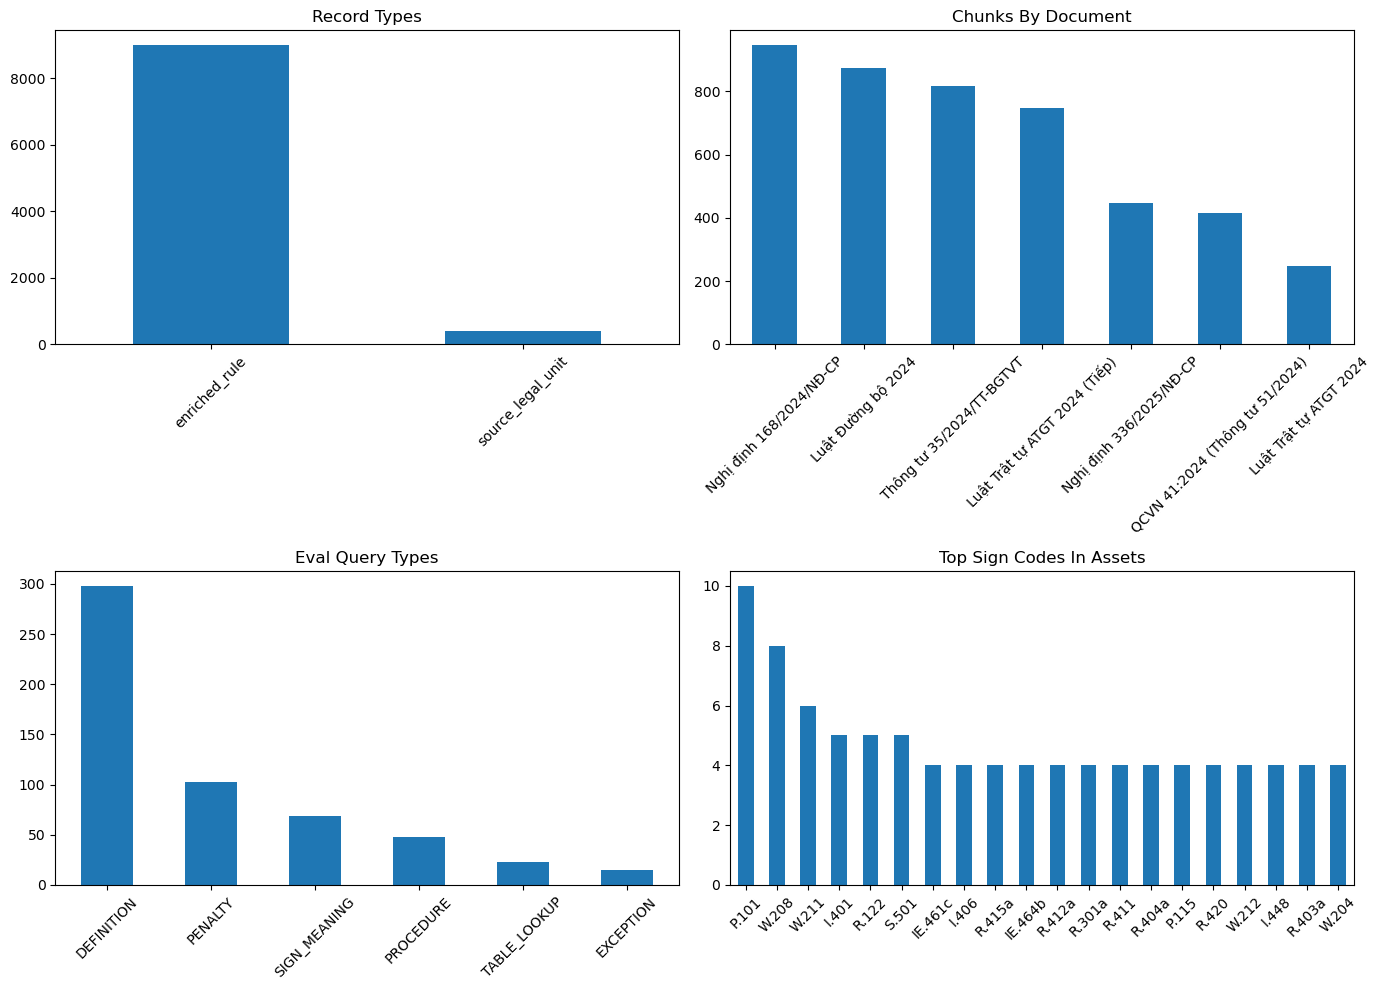

In [48]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is not None and pd is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    pd.Series(record_type_counts).sort_values(ascending=False).head(15).plot(kind="bar", ax=axes[0, 0], title="Record Types")
    pd.Series(Counter(c.get("doc_name", "missing") for c in all_chunks)).sort_values(ascending=False).plot(kind="bar", ax=axes[0, 1], title="Chunks By Document")
    pd.Series(Counter(x.get("query_type", "missing") for x in eval_items)).sort_values(ascending=False).head(15).plot(kind="bar", ax=axes[1, 0], title="Eval Query Types")
    pd.Series(Counter(sign_codes_from_meta)).sort_values(ascending=False).head(20).plot(kind="bar", ax=axes[1, 1], title="Top Sign Codes In Assets")

    for ax in axes.flat:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
else:
    print("Install pandas and matplotlib to render charts.")

## Final Assessment

### Current Data Status

Dữ liệu hiện có đủ nền tảng để chạy RAG pipeline và reindex thử nghiệm:

- 7 PDF gốc đã có trong `data/raw`.
- 9,398 extracted records đã được tạo từ pipeline extraction.
- 4,494 chunks đã có trong `data/chunks` để phục vụ retrieval.
- 649 sign asset metadata entries và 659 ảnh crop biển báo đã tồn tại.
- 871 records có dữ liệu bảng hoặc tham chiếu bảng.
- 556 handmade QA dùng được cho kiểm tra có kiểm soát.
- 12,547 synthetic QA dùng được cho stress test và kiểm tra coverage rộng.
- 556 eval items dùng được cho RAG evaluator.

### What Is Good

- Records không thiếu `legal_reference`, nên phần citation/căn cứ pháp lý có nền tảng tốt.
- Sign assets tương đối đầy đủ: metadata không trỏ tới ảnh crop bị thiếu.
- Bộ handmade QA không thiếu question, answer, legal basis hoặc reference text.
- Eval set có đủ question, gold answer và reference quote.
- Dữ liệu đã bao phủ nhiều route chính: legal definition, penalty, procedure, sign meaning và table lookup.

### Main Risks

- Có 7 duplicate record IDs. Đây là lỗi cần sửa vì có thể gây ghi đè record trong store hoặc citation sai.
- Có 656 `source_chunk_id` từ records không tồn tại trong chunk index. Điều này làm suy yếu truy vết evidence.
- Có 102 expected chunks trong eval không tồn tại trong chunk index. Retrieval metric hiện có thể bị giảm bởi lỗi lệch dữ liệu, không chỉ bởi lỗi retriever.
- Có 1,577 synthetic QA trỏ tới chunks không còn tồn tại. Không nên dùng toàn bộ synthetic QA làm chuẩn đánh giá retrieval nếu chưa remap/lọc lại.
- `table_image_files=0`, nên hiện tại table retrieval chỉ nên dựa vào JSON structured data. Nếu cần trả lời kèm ảnh bảng, phải bổ sung bước crop ảnh bảng.
- Một số chunks quá ngắn hoặc quá dài. Điều này có thể làm retrieval thiếu ngữ cảnh hoặc lấy dư nhiễu.

### Final Evaluation

Dataset hiện **đủ để phát triển, debug và chạy RAG evaluation thử nghiệm**, nhưng **chưa nên coi retrieval metrics là kết luận chính thức** cho chất lượng hệ thống.

Lý do chính là các lỗi mapping giữa records, synthetic QA, eval ground truth và chunk index. Khi expected chunks hoặc source chunks không tồn tại, evaluator sẽ phạt retrieval dù retriever có thể không phải nguyên nhân chính.

### Recommended Next Steps

1. Sửa duplicate record IDs trong extraction output.
2. Rebuild hoặc remap `source_chunk_id` để records, QA và eval cùng trỏ về chunk index hiện tại.
3. Cập nhật eval ground truth để mọi `expected_chunks` đều tồn tại trong `data/chunks`.
4. Chạy lại notebook EDA để xác nhận các lỗi `FAIL` đã hết.
5. Sau đó mới dùng retrieval metrics như hit rate, recall@k, MRR và citation accuracy làm chỉ số đánh giá chính thức.

Kết luận: dữ liệu đã đạt mức dùng được cho engineering iteration, nhưng cần làm sạch mapping/citation.